In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import pymaster as nmt

# from astropy.io import fits
# from astropy.table import Table
# from astropy.utils.data import get_pkg_data_filename
# import pandas as pd

# load the RGB values from file
from matplotlib.colors import ListedColormap

# nside_test = 1024

### read map and mask

In [2]:
# galaxy map
gal = hp.read_map("../galaxy_samples/1_delta.fits", field=0)
nside_gal = hp.get_nside(gal)

mask = hp.read_map("../masks/mask.fits")

### map visualisation

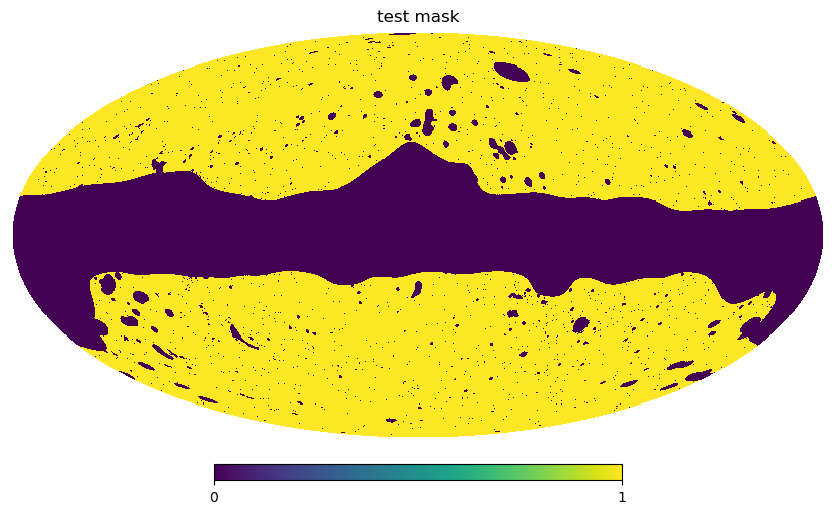

In [ ]:
# hp.mollview(mask, title="test mask")
# plt.show()

# gal_masked = gal * mask
# hp.mollview(gal_masked, title="masked galaxy map")
# plt.show()

#### compute MASTER estimator

In [3]:
b = nmt.NmtBin.from_nside_linear(nside_gal, 100)
gal_field = nmt.NmtField(mask, [gal])

cl_gal = nmt.compute_full_master(gal_field, gal_field, b)

### apply mask to the galaxy map

In [4]:
cmap = plt.cm.viridis.copy()
cmap.set_bad("gray")
cmap.set_under("white")

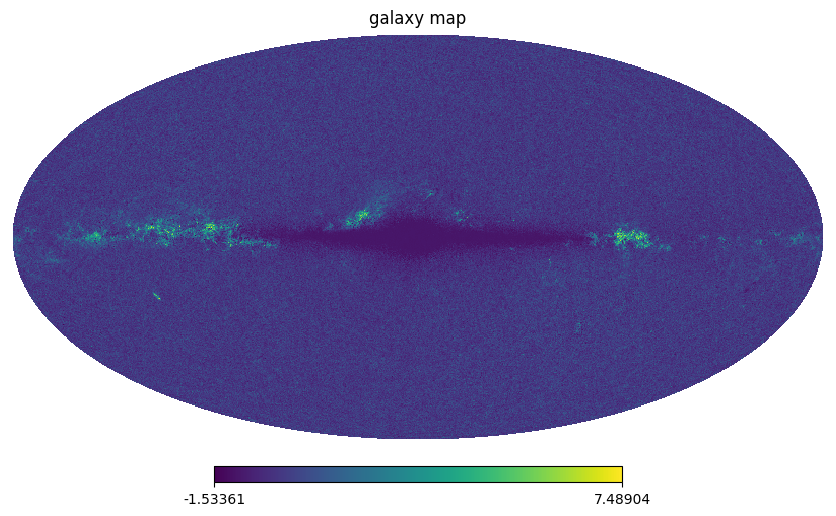

In [5]:
alm_gal = hp.map2alm(gal, lmax=3000)
gal_map = hp.alm2map(alm_gal, lmax=3000, nside=nside_gal)

hp.mollview(gal_map, title="galaxy map")
plt.show()

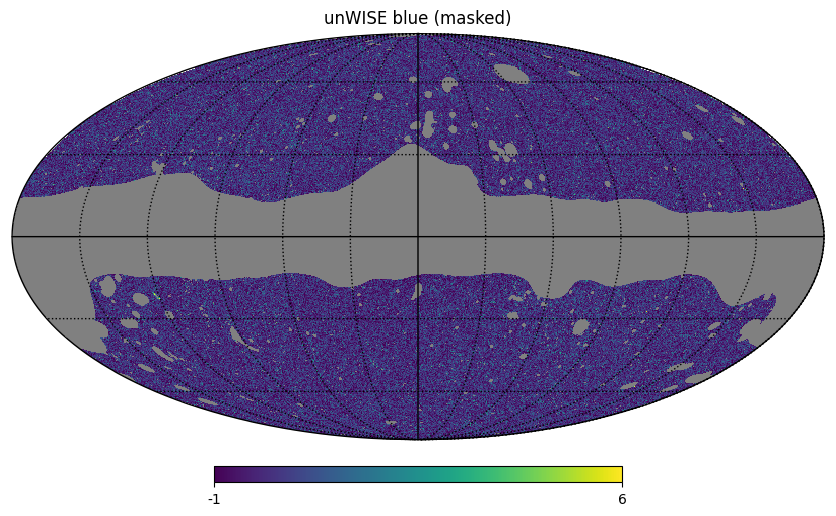

In [6]:
gal_masked = gal * mask
gal_masked = np.where(mask > 0, gal, hp.UNSEEN)
hp.mollview(
    gal_masked,
    title="unWISE blue (masked)",
    cmap = cmap, min=-1, max=6)
hp.graticule()

# hp.mollview(gal_masked, coord=['G','C'])
plt.show()

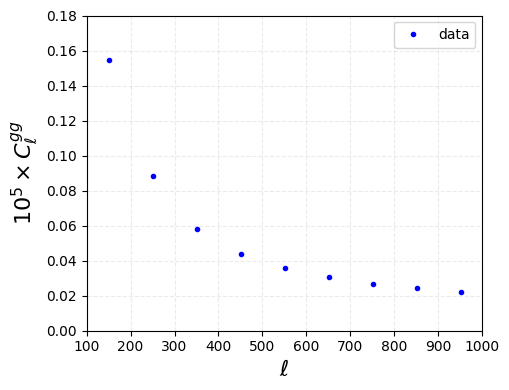

In [7]:
ell_arr = b.get_effective_ells()
cl_gg = 1e5 * cl_gal[0]

fig, ax = plt.subplots(figsize=(5.2, 4.0))

ax.errorbar(
    ell_arr,
    cl_gg,
    yerr=None,          # replace with your error array if you have one
    fmt='o',
    color='blue',
    markersize=3,
    capsize=3,
    elinewidth=1,
    label='data'
)

ax.set_xlim(100, 1000)
ax.set_ylim(0, 0.18)

ax.set_xlabel(r'$\ell$', fontsize=16)
ax.set_ylabel(r'$10^5 \times C_\ell^{gg}$', fontsize=16)

ax.grid(True, alpha=0.25, linestyle='--')
ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()